In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results__.html
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/final_waste_research_metadata_v1.0.zip
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__notebook__.ipynb
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__output__.json
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/custom.css
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test_bangladesh.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/validation.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test_international.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/train.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset

In [2]:
# ============================================================
# EfficientNet-B0 RESEARCH PIPELINE
# STEP 00 — IMPORTS
# ============================================================

import os
import gc
import json
import random
import shutil
import time
import math
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.models import (
    densenet121,
    DenseNet121_Weights
)

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

print("=" * 80)
print("EfficientNet-B0 RESEARCH PIPELINE")
print("=" * 80)

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)

EfficientNet-B0 RESEARCH PIPELINE
PyTorch     : 2.10.0+cu128
TorchVision : 0.25.0+cu128


In [3]:
# ============================================================
# STEP 01 — TRAINING ENVIRONMENT
# ============================================================

print("=" * 80)
print("TRAINING ENVIRONMENT")
print("=" * 80)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU             :", torch.cuda.get_device_name(0))

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU Memory      : {gpu_memory:.2f} GB"
    )

    DEVICE = torch.device("cuda")

else:

    print("⚠️ CUDA GPU NOT AVAILABLE")

    DEVICE = torch.device("cpu")

print("\nUsing device:", DEVICE)

TRAINING ENVIRONMENT
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
GPU Memory      : 14.56 GB

Using device: cuda


In [4]:
# ============================================================
# STEP 02 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Random seed:", SEED)

✓ Random seed: 42


In [5]:
# ============================================================
# STEP 03 — PATH DISCOVERY
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

print("=" * 80)
print("SEARCHING FOR FINAL DATASET")
print("=" * 80)

metadata_candidates = list(
    KAGGLE_INPUT.rglob("Final_Waste_Dataset/research_metadata")
)

if not metadata_candidates:

    metadata_candidates = list(
        KAGGLE_INPUT.rglob("research_metadata")
    )

print("\nMetadata candidates:")

for p in metadata_candidates:
    print("→", p)

if not metadata_candidates:

    raise FileNotFoundError(
        "Final_Waste_Dataset/research_metadata not found."
    )

META = metadata_candidates[0]

print("\nSelected META:")
print(META)

SEARCHING FOR FINAL DATASET

Metadata candidates:
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

Selected META:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata


In [6]:
# ============================================================
# STEP 04 — IMAGE ROOT DISCOVERY
# ============================================================

possible_image_roots = []

for root in [
    KAGGLE_INPUT,
    KAGGLE_WORKING
]:

    if root.exists():

        for p in root.rglob("images"):

            if not p.is_dir():
                continue

            try:

                classes_found = {
                    x.name
                    for x in p.iterdir()
                    if x.is_dir()
                }

            except Exception:

                continue

            required = {
                "Cardboard",
                "Glass",
                "Metal",
                "Paper",
                "Plastic"
            }

            if required.issubset(classes_found):

                possible_image_roots.append(p)

print("=" * 80)
print("IMAGE ROOT CANDIDATES")
print("=" * 80)

for p in possible_image_roots:

    print("→", p)

if not possible_image_roots:

    raise FileNotFoundError(
        "Could not find image root containing all 5 classes."
    )

IMAGE_ROOT = possible_image_roots[0]

print("\nIMAGE_ROOT:")
print(IMAGE_ROOT)

IMAGE ROOT CANDIDATES
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images

IMAGE_ROOT:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images


In [7]:
# ============================================================
# STEP 05 — METADATA PATHS
# ============================================================

FINAL_METADATA = META / "final_metadata.csv"
TRAIN_METADATA = META / "train_final.csv"
VAL_METADATA = META / "validation_final.csv"
TEST_METADATA = META / "test_final.csv"

BD_TEST_METADATA = META / "test_bangladesh_final.csv"
INTL_TEST_METADATA = META / "test_international_final.csv"

required_files = [
    FINAL_METADATA,
    TRAIN_METADATA,
    VAL_METADATA,
    TEST_METADATA,
    BD_TEST_METADATA,
    INTL_TEST_METADATA
]

print("=" * 80)
print("METADATA FILE CHECK")
print("=" * 80)

for p in required_files:

    if p.exists():

        print("✓", p)

    else:

        print("✗", p)
        raise FileNotFoundError(p)

METADATA FILE CHECK
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/final_metadata.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/train_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/validation_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_bangladesh_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_international_final.csv


In [8]:
# ============================================================
# STEP 06 — LOAD METADATA
# ============================================================

final_df = pd.read_csv(FINAL_METADATA)
train_df = pd.read_csv(TRAIN_METADATA)
val_df = pd.read_csv(VAL_METADATA)
test_df = pd.read_csv(TEST_METADATA)

bd_test_original = pd.read_csv(BD_TEST_METADATA)
intl_test_original = pd.read_csv(INTL_TEST_METADATA)

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print("Final       :", len(final_df))
print("Train       :", len(train_df))
print("Validation  :", len(val_df))
print("Test        :", len(test_df))
print("BD CSV      :", len(bd_test_original))
print("Intl CSV    :", len(intl_test_original))

DATASET LOADED
Final       : 10668
Train       : 7245
Validation  : 1552
Test        : 1871
BD CSV      : 319
Intl CSV    : 1289


In [9]:
# ============================================================
# STEP 07 — METADATA COLUMN AUDIT
# ============================================================

print("=" * 80)
print("METADATA COLUMN AUDIT")
print("=" * 80)

datasets = {
    "final": final_df,
    "train": train_df,
    "validation": val_df,
    "test": test_df,
    "bangladesh_original": bd_test_original,
    "international_original": intl_test_original
}

required_columns = [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group",
    "original_path"
]

for name, df in datasets.items():

    print(f"\n{name.upper()}")

    print(df.columns.tolist())

    missing_columns = [
        c for c in required_columns
        if c not in df.columns
    ]

    if missing_columns:

        raise ValueError(
            f"{name} missing columns: {missing_columns}"
        )

print("\n✓ Metadata schema valid")

METADATA COLUMN AUDIT

FINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TRAIN
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

VALIDATION
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TEST
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

BANGLADESH_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

INTERNATIONAL_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

✓ Metadata schema valid


In [10]:
# ============================================================
# STEP 08 — DATASET SPLIT AUDIT
# ============================================================

print("=" * 80)
print("DATASET COUNT AUDIT")
print("=" * 80)

print(f"Final metadata : {len(final_df):,}")
print(f"Train          : {len(train_df):,}")
print(f"Validation     : {len(val_df):,}")
print(f"Test           : {len(test_df):,}")

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("\nTrain + Validation + Test:", split_total)

if split_total != len(final_df):

    raise ValueError(
        "Dataset split mismatch. STOP."
    )

print("\n✓ Split totals match")

DATASET COUNT AUDIT
Final metadata : 10,668
Train          : 7,245
Validation     : 1,552
Test           : 1,871

Train + Validation + Test: 10668

✓ Split totals match


In [11]:
# ============================================================
# STEP 09 — RECONSTRUCT COMPLETE TEST GROUPS
# ============================================================

print("=" * 80)
print("RECONSTRUCTING COMPLETE TEST GROUPS")
print("=" * 80)

test_work = test_df.copy()

# ------------------------------------------------------------
# Normalize text fields
# ------------------------------------------------------------

for col in [
    "filename",
    "source",
    "country",
    "dataset_group"
]:

    test_work[col] = (
        test_work[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# ------------------------------------------------------------
# Normalize filename
# ------------------------------------------------------------

test_work["filename_key"] = (
    test_work["filename"]
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Build groups DIRECTLY from final test metadata
# ------------------------------------------------------------

bd_test_df = test_work[
    (
        test_work["source"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["country"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["dataset_group"].str.lower() == "bangladesh"
    )
].copy()

international_test_df = test_work[
    ~test_work["filename_key"].isin(
        set(bd_test_df["filename_key"])
    )
].copy()

# ------------------------------------------------------------
# Remove helper column later
# ------------------------------------------------------------

print("Overall test       :", len(test_work))
print("Bangladesh test    :", len(bd_test_df))
print("International test :", len(international_test_df))

print(
    "\nBD + International :",
    len(bd_test_df) + len(international_test_df)
)

if (
    len(bd_test_df)
    + len(international_test_df)
    != len(test_work)
):

    raise ValueError(
        "Test group reconstruction failed."
    )

print("\n✓ Complete test group coverage restored")

RECONSTRUCTING COMPLETE TEST GROUPS
Overall test       : 1871
Bangladesh test    : 582
International test : 1289

BD + International : 1871

✓ Complete test group coverage restored


In [12]:
# ============================================================
# STEP 09 — RECONSTRUCT COMPLETE TEST GROUPS
# ============================================================

print("=" * 80)
print("RECONSTRUCTING COMPLETE TEST GROUPS")
print("=" * 80)

test_work = test_df.copy()

# ------------------------------------------------------------
# Normalize text fields
# ------------------------------------------------------------

for col in [
    "filename",
    "source",
    "country",
    "dataset_group"
]:

    test_work[col] = (
        test_work[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# ------------------------------------------------------------
# Normalize filename
# ------------------------------------------------------------

test_work["filename_key"] = (
    test_work["filename"]
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Build groups DIRECTLY from final test metadata
# ------------------------------------------------------------

bd_test_df = test_work[
    (
        test_work["source"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["country"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["dataset_group"].str.lower() == "bangladesh"
    )
].copy()

international_test_df = test_work[
    ~test_work["filename_key"].isin(
        set(bd_test_df["filename_key"])
    )
].copy()

# ------------------------------------------------------------
# Remove helper column later
# ------------------------------------------------------------

print("Overall test       :", len(test_work))
print("Bangladesh test    :", len(bd_test_df))
print("International test :", len(international_test_df))

print(
    "\nBD + International :",
    len(bd_test_df) + len(international_test_df)
)

if (
    len(bd_test_df)
    + len(international_test_df)
    != len(test_work)
):

    raise ValueError(
        "Test group reconstruction failed."
    )

print("\n✓ Complete test group coverage restored")

RECONSTRUCTING COMPLETE TEST GROUPS
Overall test       : 1871
Bangladesh test    : 582
International test : 1289

BD + International : 1871

✓ Complete test group coverage restored


In [13]:
# ============================================================
# STEP 11 — CLASS CONFIGURATION
# ============================================================

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {
    idx: cls
    for cls, idx in CLASS_TO_IDX.items()
}

print("=" * 80)
print("CLASS MAPPING")
print("=" * 80)

for cls, idx in CLASS_TO_IDX.items():

    print(f"{cls:<12} : {idx}")

CLASS MAPPING
Cardboard    : 0
Glass        : 1
Metal        : 2
Paper        : 3
Plastic      : 4


In [14]:
# ============================================================
# STEP 12 — CLASS AUDIT
# ============================================================

print("=" * 80)
print("CLASS AUDIT")
print("=" * 80)

for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():

    classes = sorted(
        df["class"].dropna().unique().tolist()
    )

    print(f"\n{name}:")
    print(classes)

    if set(classes) != set(CLASS_NAMES):

        raise ValueError(
            f"{name} does not contain all 5 classes."
        )

print("\n✓ All 5 classes present")

CLASS AUDIT

train:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

validation:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

test:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

✓ All 5 classes present


In [15]:
# ============================================================
# RESTORE FINAL RESEARCH METADATA
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# CORRECT KAGGLE INPUT PATH
# ------------------------------------------------------------

META = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata"
)

print("=" * 80)
print("RESTORING FINAL RESEARCH METADATA")
print("=" * 80)

print("Metadata directory:")
print(META)

# ------------------------------------------------------------
# CHECK DIRECTORY
# ------------------------------------------------------------

if not META.exists():
    raise FileNotFoundError(
        f"Metadata directory not found:\n{META}"
    )

print("\n✓ Metadata directory found")

print("\nAvailable files:")

for f in sorted(META.iterdir()):
    print(" -", f.name)

# ------------------------------------------------------------
# LOAD METADATA
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

# ------------------------------------------------------------
# RESTORE SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET RESTORED SUCCESSFULLY")
print("=" * 80)

print(
    f"Final metadata       : {len(final_df):,}"
)

print(
    f"Train                : {len(train_df):,}"
)

print(
    f"Validation           : {len(val_df):,}"
)

print(
    f"Overall Test         : {len(test_df):,}"
)

print(
    f"Bangladesh Test      : {len(bd_test):,}"
)

print(
    f"International Test   : {len(international_test_df):,}"
)

# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CONSISTENCY CHECK")
print("-" * 80)

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print(
    f"Train + Validation + Test : {split_total:,}"
)

print(
    f"Final metadata            : {len(final_df):,}"
)

print(
    "MATCH                     :",
    split_total == len(final_df)
)

# ------------------------------------------------------------
# BASIC DATA CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLASS DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["class"]
    .value_counts()
    .sort_index()
)

print("\n" + "-" * 80)
print("SOURCE DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["source"]
    .value_counts()
)

print("\n✓ METADATA RESTORATION COMPLETE")

RESTORING FINAL RESEARCH METADATA
Metadata directory:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

✓ Metadata directory found

Available files:
 - FINAL_CHECKPOINT.json
 - final_metadata.csv
 - manual_review_decisions.csv
 - test_bangladesh_final.csv
 - test_final.csv
 - test_international_final.csv
 - train_final.csv
 - training_class_balance.csv
 - validation_final.csv

DATASET RESTORED SUCCESSFULLY
Final metadata       : 10,668
Train                : 7,245
Validation           : 1,552
Overall Test         : 1,871
Bangladesh Test      : 319
International Test   : 1,289

--------------------------------------------------------------------------------
CONSISTENCY CHECK
--------------------------------------------------------------------------------
Train + Validation + Test : 10,668
Final metadata            : 10,668
MATCH                     : True

--------------------------------------------------------------------------------
CLASS

# RESTORE FINAL RESEARCH METADATA

In [16]:
# ============================================================
# RESTORE FINAL RESEARCH METADATA
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# CORRECT KAGGLE INPUT PATH
# ------------------------------------------------------------

META = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata"
)

print("=" * 80)
print("RESTORING FINAL RESEARCH METADATA")
print("=" * 80)

print("Metadata directory:")
print(META)

# ------------------------------------------------------------
# CHECK DIRECTORY
# ------------------------------------------------------------

if not META.exists():
    raise FileNotFoundError(
        f"Metadata directory not found:\n{META}"
    )

print("\n✓ Metadata directory found")

print("\nAvailable files:")

for f in sorted(META.iterdir()):
    print(" -", f.name)

# ------------------------------------------------------------
# LOAD METADATA
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

# ------------------------------------------------------------
# RESTORE SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET RESTORED SUCCESSFULLY")
print("=" * 80)

print(
    f"Final metadata       : {len(final_df):,}"
)

print(
    f"Train                : {len(train_df):,}"
)

print(
    f"Validation           : {len(val_df):,}"
)

print(
    f"Overall Test         : {len(test_df):,}"
)

print(
    f"Bangladesh Test      : {len(bd_test):,}"
)

print(
    f"International Test   : {len(international_test_df):,}"
)

# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CONSISTENCY CHECK")
print("-" * 80)

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print(
    f"Train + Validation + Test : {split_total:,}"
)

print(
    f"Final metadata            : {len(final_df):,}"
)

print(
    "MATCH                     :",
    split_total == len(final_df)
)

# ------------------------------------------------------------
# BASIC DATA CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLASS DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["class"]
    .value_counts()
    .sort_index()
)

print("\n" + "-" * 80)
print("SOURCE DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["source"]
    .value_counts()
)

print("\n✓ METADATA RESTORATION COMPLETE")

RESTORING FINAL RESEARCH METADATA
Metadata directory:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

✓ Metadata directory found

Available files:
 - FINAL_CHECKPOINT.json
 - final_metadata.csv
 - manual_review_decisions.csv
 - test_bangladesh_final.csv
 - test_final.csv
 - test_international_final.csv
 - train_final.csv
 - training_class_balance.csv
 - validation_final.csv

DATASET RESTORED SUCCESSFULLY
Final metadata       : 10,668
Train                : 7,245
Validation           : 1,552
Overall Test         : 1,871
Bangladesh Test      : 319
International Test   : 1,289

--------------------------------------------------------------------------------
CONSISTENCY CHECK
--------------------------------------------------------------------------------
Train + Validation + Test : 10,668
Final metadata            : 10,668
MATCH                     : True

--------------------------------------------------------------------------------
CLASS

# REPRODUCIBILITY

In [17]:
# ============================================================
# STEP 02 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=" * 80)
print("REPRODUCIBILITY CONFIGURATION")
print("=" * 80)

print("Seed:", SEED)
print("✓ Reproducibility configuration applied")

REPRODUCIBILITY CONFIGURATION
Seed: 42
✓ Reproducibility configuration applied


#  GLOBAL CONFIGURATION

In [18]:
# ============================================================
# STEP 03 — GLOBAL CONFIGURATION
# ============================================================

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {
    idx: name
    for name, idx in CLASS_TO_IDX.items()
}

NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32

EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 7

NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()

print("=" * 80)
print("MOBILENETV3-LARGE CONFIGURATION")
print("=" * 80)

print("Classes       :", CLASS_NAMES)
print("Num classes   :", NUM_CLASSES)
print("Image size    :", IMG_SIZE)
print("Batch size    :", BATCH_SIZE)
print("Epochs        :", EPOCHS)
print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)
print("Patience      :", PATIENCE)
print("Workers       :", NUM_WORKERS)

MOBILENETV3-LARGE CONFIGURATION
Classes       : ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
Num classes   : 5
Image size    : 224
Batch size    : 32
Epochs        : 30
Learning rate : 0.0001
Weight decay  : 0.0001
Patience      : 7
Workers       : 2


# OUTPUT DIRECTORIES

In [19]:
# ============================================================
# STEP 04 — OUTPUT DIRECTORIES
# ============================================================

OUTPUT_ROOT = Path(
    "/kaggle/working/mobilenetv3_large_experiment"
)

CHECKPOINT_DIR = (
    OUTPUT_ROOT / "checkpoints"
)

REPORT_DIR = (
    OUTPUT_ROOT / "reports"
)

VIS_DIR = (
    OUTPUT_ROOT / "visualizations"
)

RESULT_DIR = (
    OUTPUT_ROOT / "results"
)

for directory in [
    OUTPUT_ROOT,
    CHECKPOINT_DIR,
    REPORT_DIR,
    VIS_DIR,
    RESULT_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 80)
print("OUTPUT DIRECTORIES")
print("=" * 80)

print("Output root :", OUTPUT_ROOT)
print("Checkpoints :", CHECKPOINT_DIR)
print("Reports     :", REPORT_DIR)
print("Visuals     :", VIS_DIR)
print("Results     :", RESULT_DIR)

print("\n✓ Output directories ready")

OUTPUT DIRECTORIES
Output root : /kaggle/working/mobilenetv3_large_experiment
Checkpoints : /kaggle/working/mobilenetv3_large_experiment/checkpoints
Reports     : /kaggle/working/mobilenetv3_large_experiment/reports
Visuals     : /kaggle/working/mobilenetv3_large_experiment/visualizations
Results     : /kaggle/working/mobilenetv3_large_experiment/results

✓ Output directories ready


#  PATH DISCOVERY

In [20]:
# ============================================================
# STEP 05 — PATH DISCOVERY
# ============================================================

KAGGLE_INPUT = Path(
    "/kaggle/input"
)

KAGGLE_WORKING = Path(
    "/kaggle/working"
)

print("=" * 80)
print("SEARCHING FOR FINAL DATASET")
print("=" * 80)

metadata_candidates = list(
    KAGGLE_INPUT.rglob(
        "Final_Waste_Dataset/research_metadata"
    )
)

if not metadata_candidates:

    metadata_candidates = list(
        KAGGLE_INPUT.rglob(
            "research_metadata"
        )
    )

print("\nMetadata candidates:")

for path in metadata_candidates:

    print("→", path)

if not metadata_candidates:

    raise FileNotFoundError(
        "Final_Waste_Dataset/research_metadata "
        "was not found under /kaggle/input."
    )

META = metadata_candidates[0]

print("\nSelected META:")
print(META)

SEARCHING FOR FINAL DATASET

Metadata candidates:
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

Selected META:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata


# IMAGE ROOT DISCOVERY

In [21]:
# ============================================================
# STEP 06 — IMAGE ROOT DISCOVERY
# ============================================================

required_classes = set(
    CLASS_NAMES
)

possible_image_roots = []

for root in [
    KAGGLE_INPUT,
    KAGGLE_WORKING
]:

    if not root.exists():
        continue

    for path in root.rglob("images"):

        if not path.is_dir():
            continue

        try:

            classes_found = {
                item.name
                for item in path.iterdir()
                if item.is_dir()
            }

        except Exception:

            continue

        if required_classes.issubset(
            classes_found
        ):

            possible_image_roots.append(
                path
            )

print("=" * 80)
print("IMAGE ROOT CANDIDATES")
print("=" * 80)

for path in possible_image_roots:

    print("→", path)

if not possible_image_roots:

    raise FileNotFoundError(
        "Could not find image root containing "
        "all 5 required classes."
    )

IMAGE_ROOT = possible_image_roots[0]

print("\nIMAGE_ROOT:")
print(IMAGE_ROOT)

IMAGE ROOT CANDIDATES
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images

IMAGE_ROOT:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images


# METADATA PATHS

In [22]:
# ============================================================
# STEP 07 — METADATA PATHS
# ============================================================

FINAL_METADATA = (
    META / "final_metadata.csv"
)

TRAIN_METADATA = (
    META / "train_final.csv"
)

VAL_METADATA = (
    META / "validation_final.csv"
)

TEST_METADATA = (
    META / "test_final.csv"
)

BD_TEST_METADATA = (
    META / "test_bangladesh_final.csv"
)

INTL_TEST_METADATA = (
    META / "test_international_final.csv"
)

required_metadata_files = [
    FINAL_METADATA,
    TRAIN_METADATA,
    VAL_METADATA,
    TEST_METADATA,
    BD_TEST_METADATA,
    INTL_TEST_METADATA
]

print("=" * 80)
print("METADATA FILE CHECK")
print("=" * 80)

for path in required_metadata_files:

    if path.exists():

        print("✓", path)

    else:

        print("✗", path)

        raise FileNotFoundError(
            path
        )

print("\n✓ All metadata files found")

METADATA FILE CHECK
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/final_metadata.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/train_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/validation_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_bangladesh_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_international_final.csv

✓ All metadata files found


# LOAD METADATA

In [23]:
# ============================================================
# STEP 08 — LOAD METADATA
# ============================================================

final_df = pd.read_csv(
    FINAL_METADATA
)

train_df = pd.read_csv(
    TRAIN_METADATA
)

val_df = pd.read_csv(
    VAL_METADATA
)

test_df = pd.read_csv(
    TEST_METADATA
)

bd_test_original = pd.read_csv(
    BD_TEST_METADATA
)

intl_test_original = pd.read_csv(
    INTL_TEST_METADATA
)

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print(
    f"Final metadata : {len(final_df):,}"
)

print(
    f"Train          : {len(train_df):,}"
)

print(
    f"Validation     : {len(val_df):,}"
)

print(
    f"Test           : {len(test_df):,}"
)

print(
    f"BD original    : {len(bd_test_original):,}"
)

print(
    f"Intl original  : {len(intl_test_original):,}"
)

DATASET LOADED
Final metadata : 10,668
Train          : 7,245
Validation     : 1,552
Test           : 1,871
BD original    : 319
Intl original  : 1,289


# METADATA SCHEMA AUDIT

In [24]:
# ============================================================
# STEP 09 — METADATA SCHEMA AUDIT
# ============================================================

required_columns = [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group",
    "original_path"
]

datasets_for_audit = {

    "final":
        final_df,

    "train":
        train_df,

    "validation":
        val_df,

    "test":
        test_df,

    "bangladesh_original":
        bd_test_original,

    "international_original":
        intl_test_original
}

print("=" * 80)
print("METADATA COLUMN AUDIT")
print("=" * 80)

for name, df in datasets_for_audit.items():

    print(f"\n{name.upper()}")

    print(
        df.columns.tolist()
    )

    missing_columns = [
        col
        for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:

        raise ValueError(
            f"{name} missing columns: "
            f"{missing_columns}"
        )

print("\n✓ Metadata schema valid")

METADATA COLUMN AUDIT

FINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TRAIN
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

VALIDATION
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TEST
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

BANGLADESH_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

INTERNATIONAL_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

✓ Metadata schema valid


# DATASET SPLIT AUDIT

In [25]:
# ============================================================
# STEP 10 — DATASET SPLIT AUDIT
# ============================================================

print("=" * 80)
print("DATASET SPLIT AUDIT")
print("=" * 80)

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print(
    f"Final metadata : {len(final_df):,}"
)

print(
    f"Train          : {len(train_df):,}"
)

print(
    f"Validation     : {len(val_df):,}"
)

print(
    f"Test           : {len(test_df):,}"
)

print(
    f"\nSplit total    : {split_total:,}"
)

if split_total != len(final_df):

    raise ValueError(
        "Train + Validation + Test "
        "does not equal final metadata."
    )

print("\n✓ Dataset split is valid")

DATASET SPLIT AUDIT
Final metadata : 10,668
Train          : 7,245
Validation     : 1,552
Test           : 1,871

Split total    : 10,668

✓ Dataset split is valid


# RECONSTRUCT COMPLETE TEST GROUPS

In [26]:
# ============================================================
# STEP 11 — RECONSTRUCT COMPLETE TEST GROUPS
# ============================================================

print("=" * 80)
print("RECONSTRUCTING COMPLETE TEST GROUPS")
print("=" * 80)

test_work = test_df.copy()

for col in [
    "filename",
    "source",
    "country",
    "dataset_group"
]:

    test_work[col] = (
        test_work[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

test_work["filename_key"] = (
    test_work["filename"]
    .str.lower()
)

# ------------------------------------------------------------
# Bangladesh
# ------------------------------------------------------------

bd_mask = (
    test_work["source"]
    .str.lower()
    .eq("bangladesh")
)

bd_mask |= (
    test_work["country"]
    .str.lower()
    .eq("bangladesh")
)

bd_mask |= (
    test_work["dataset_group"]
    .str.lower()
    .eq("bangladesh")
)

bd_test_df = test_work[
    bd_mask
].copy()

# ------------------------------------------------------------
# International
# ------------------------------------------------------------

international_test_df = test_work[
    ~test_work["filename_key"].isin(
        set(
            bd_test_df[
                "filename_key"
            ]
        )
    )
].copy()

print(
    f"Overall test       : "
    f"{len(test_work):,}"
)

print(
    f"Bangladesh test    : "
    f"{len(bd_test_df):,}"
)

print(
    f"International test : "
    f"{len(international_test_df):,}"
)

group_total = (
    len(bd_test_df)
    + len(international_test_df)
)

print(
    f"BD + International : "
    f"{group_total:,}"
)

if group_total != len(test_work):

    raise ValueError(
        "Bangladesh + International "
        "does not cover complete test set."
    )

if (
    set(bd_test_df["filename_key"])
    &
    set(international_test_df["filename_key"])
):

    raise ValueError(
        "Bangladesh/International overlap detected."
    )

print(
    "\n✓ Complete test group coverage restored"
)

RECONSTRUCTING COMPLETE TEST GROUPS
Overall test       : 1,871
Bangladesh test    : 582
International test : 1,289
BD + International : 1,871

✓ Complete test group coverage restored


# CLASS AUDIT

In [27]:
# ============================================================
# STEP 12 — CLASS AUDIT
# ============================================================

print("=" * 80)
print("CLASS AUDIT")
print("=" * 80)

for name, df in {

    "train": train_df,

    "validation": val_df,

    "test": test_df,

    "bangladesh_test":
        bd_test_df,

    "international_test":
        international_test_df

}.items():

    classes = sorted(
        df["class"]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"\n{name}:")
    print(classes)

    if set(classes) != set(
        CLASS_NAMES
    ):

        raise ValueError(
            f"{name} does not contain "
            f"all required classes."
        )

print(
    "\n✓ All 5 classes present everywhere"
)

CLASS AUDIT

train:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

validation:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

test:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

bangladesh_test:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

international_test:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

✓ All 5 classes present everywhere


# TRAIN CLASS DISTRIBUTION

In [28]:
# ============================================================
# STEP 13 — TRAIN CLASS DISTRIBUTION
# ============================================================

train_class_counts = (
    train_df["class"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("=" * 80)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 80)

print(train_class_counts)

if train_class_counts.isna().any():

    raise ValueError(
        "Missing class in training distribution."
    )

max_count = train_class_counts.max()
min_count = train_class_counts.min()

imbalance_ratio = (
    max_count / min_count
)

print(
    f"\nMaximum : {max_count:,}"
)

print(
    f"Minimum : {min_count:,}"
)

print(
    f"Imbalance ratio : "
    f"{imbalance_ratio:.4f}"
)

TRAINING CLASS DISTRIBUTION
class
Cardboard    1193
Glass        1433
Metal        1594
Paper        1793
Plastic      1232
Name: count, dtype: int64

Maximum : 1,793
Minimum : 1,193
Imbalance ratio : 1.5029


# CLASS WEIGHTS

In [29]:
# ============================================================
# STEP 14 — CLASS WEIGHTS
# ============================================================

class_counts = (
    train_class_counts
    .values
    .astype(np.float64)
)

total_train = class_counts.sum()

class_weights = (
    total_train
    /
    (
        NUM_CLASSES
        * class_counts
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("=" * 80)
print("CLASS WEIGHTS")
print("=" * 80)

for class_name, weight in zip(
    CLASS_NAMES,
    class_weights
):

    print(
        f"{class_name:<12} : "
        f"{weight:.4f}"
    )

CLASS WEIGHTS
Cardboard    : 1.2146
Glass        : 1.0112
Metal        : 0.9090
Paper        : 0.8081
Plastic      : 1.1761


# IMAGE PATH RESOLUTION

In [30]:
# ============================================================
# STEP 15 — IMAGE PATH RESOLUTION
# ============================================================

def resolve_image_path(
    filename,
    class_name
):

    filename = str(
        filename
    ).strip()

    class_name = str(
        class_name
    ).strip()

    # Primary path
    primary_path = (
        IMAGE_ROOT
        / class_name
        / filename
    )

    if primary_path.exists():

        return primary_path

    # Case-insensitive fallback
    class_dir = (
        IMAGE_ROOT
        / class_name
    )

    if class_dir.exists():

        target = filename.lower()

        for candidate in class_dir.iterdir():

            if (
                candidate.name.lower()
                == target
            ):

                return candidate

    return None


print("=" * 80)
print("IMAGE PATH RESOLUTION TEST")
print("=" * 80)

sample = train_df.head(20)

missing_samples = []

for _, row in sample.iterrows():

    path = resolve_image_path(
        row["filename"],
        row["class"]
    )

    if path is None:

        missing_samples.append(
            row["filename"]
        )

print(
    "Missing first 20 :",
    len(missing_samples)
)

if missing_samples:

    print(
        missing_samples
    )

    raise FileNotFoundError(
        "Image path resolution failed."
    )

print(
    "\n✓ Image paths resolve correctly"
)

IMAGE PATH RESOLUTION TEST
Missing first 20 : 0

✓ Image paths resolve correctly


# FULL IMAGE EXISTENCE AUDIT

In [31]:
# ============================================================
# STEP 16 — FULL IMAGE EXISTENCE AUDIT
# ============================================================

def audit_image_paths(
    dataframe,
    dataset_name
):

    missing = []

    for _, row in dataframe.iterrows():

        path = resolve_image_path(
            row["filename"],
            row["class"]
        )

        if path is None:

            missing.append(
                row["filename"]
            )

    print(
        f"{dataset_name:<20} "
        f": {len(dataframe):,} images | "
        f"missing = {len(missing):,}"
    )

    return missing


print("=" * 80)
print("FULL IMAGE EXISTENCE AUDIT")
print("=" * 80)

train_missing = audit_image_paths(
    train_df,
    "Train"
)

val_missing = audit_image_paths(
    val_df,
    "Validation"
)

test_missing = audit_image_paths(
    test_df,
    "Test"
)

if (
    train_missing
    or val_missing
    or test_missing
):

    raise FileNotFoundError(
        "Some final dataset images are missing."
    )

print(
    "\n✓ All training/validation/test images found"
)

FULL IMAGE EXISTENCE AUDIT
Train                : 7,245 images | missing = 0
Validation           : 1,552 images | missing = 0
Test                 : 1,871 images | missing = 0

✓ All training/validation/test images found


# PYTORCH DATASET

In [32]:
# ============================================================
# STEP 17 — PYTORCH DATASET
# ============================================================

class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_root,
        transform=None
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.image_root = Path(
            image_root
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        filename = row["filename"]

        class_name = row["class"]

        image_path = resolve_image_path(
            filename,
            class_name
        )

        if image_path is None:

            raise FileNotFoundError(
                f"Image not found: "
                f"{filename}"
            )

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as error:

            raise RuntimeError(
                f"Could not open image: "
                f"{image_path}"
            ) from error

        label = CLASS_TO_IDX[
            class_name
        ]

        if self.transform:

            image = self.transform(
                image
            )

        return image, label

# MOBILE NET V3 TRANSFORMS

In [33]:
# ============================================================
# STEP 18 — TRANSFORMS
# ============================================================

imagenet_mean = [
    0.485,
    0.456,
    0.406
]

imagenet_std = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print("=" * 80)
print("TRANSFORMS READY")
print("=" * 80)

print(
    "Training augmentation : "
    "Flip + Rotation + ColorJitter"
)

print(
    "Evaluation transform  : "
    "Resize + Normalize"
)

print(
    "Image size            :",
    IMG_SIZE
)

TRANSFORMS READY
Training augmentation : Flip + Rotation + ColorJitter
Evaluation transform  : Resize + Normalize
Image size            : 224


# CREATE DATASETS

In [34]:
# ============================================================
# STEP 19 — CREATE DATASETS
# ============================================================

train_dataset = WasteDataset(
    train_df,
    IMAGE_ROOT,
    train_transform
)

valid_dataset = WasteDataset(
    val_df,
    IMAGE_ROOT,
    eval_transform
)

test_dataset = WasteDataset(
    test_df,
    IMAGE_ROOT,
    eval_transform
)

bd_test_dataset = WasteDataset(
    bd_test_df,
    IMAGE_ROOT,
    eval_transform
)

intl_test_dataset = WasteDataset(
    international_test_df,
    IMAGE_ROOT,
    eval_transform
)

print("=" * 80)
print("DATASETS CREATED")
print("=" * 80)

print(
    "Train        :",
    len(train_dataset)
)

print(
    "Validation   :",
    len(valid_dataset)
)

print(
    "Test         :",
    len(test_dataset)
)

print(
    "Bangladesh   :",
    len(bd_test_dataset)
)

print(
    "International:",
    len(intl_test_dataset)
)

DATASETS CREATED
Train        : 7245
Validation   : 1552
Test         : 1871
Bangladesh   : 582
International: 1289


# DATALOADERS

In [35]:
# ============================================================
# STEP 20 — DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

bd_test_loader = DataLoader(
    bd_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

intl_test_loader = DataLoader(
    intl_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("=" * 80)
print("DATALOADERS CREATED")
print("=" * 80)

print(
    "Train batches :",
    len(train_loader)
)

print(
    "Valid batches :",
    len(valid_loader)
)

print(
    "Test batches  :",
    len(test_loader)
)

print(
    "BD batches    :",
    len(bd_test_loader)
)

print(
    "Intl batches  :",
    len(intl_test_loader)
)

DATALOADERS CREATED
Train batches : 227
Valid batches : 49
Test batches  : 59
BD batches    : 19
Intl batches  : 41


# BATCH TEST

In [36]:
# ============================================================
# STEP 21 — BATCH TEST
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("=" * 80)
print("BATCH TEST")
print("=" * 80)

print(
    "Images shape :",
    images.shape
)

print(
    "Labels shape :",
    labels.shape
)

images_gpu = images.to(
    DEVICE,
    non_blocking=True
)

labels_gpu = labels.to(
    DEVICE,
    non_blocking=True
)

print(
    "\nImages device:",
    images_gpu.device
)

print(
    "Labels device:",
    labels_gpu.device
)

expected_shape = (
    BATCH_SIZE,
    3,
    IMG_SIZE,
    IMG_SIZE
)

assert images.shape == expected_shape

print(
    "\n✓ Batch test successful"
)

BATCH TEST
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])

Images device: cuda:0
Labels device: cuda:0

✓ Batch test successful


# OBILE NET V3 LARGE MODEL

In [37]:
# ============================================================
# STEP 22 — MOBILE NET V3 LARGE MODEL
# ============================================================
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
print("=" * 80)
print("BUILDING MOBILENETV3-LARGE")
print("=" * 80)

weights = (
    MobileNet_V3_Large_Weights.DEFAULT
)

MODEL = mobilenet_v3_large(
    weights=weights
)

# ------------------------------------------------------------
# Replace classifier
# ------------------------------------------------------------

in_features = (
    MODEL.classifier[-1].in_features
)

MODEL.classifier[-1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

MODEL = MODEL.to(
    DEVICE
)

print(
    "Classifier input features:",
    in_features
)

print(
    "Classifier output classes:",
    NUM_CLASSES
)

print(
    "\nModel device:",
    next(
        MODEL.parameters()
    ).device
)

print(
    "\n✓ MobileNetV3-Large ready"
)

BUILDING MOBILENETV3-LARGE
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 149MB/s]


Classifier input features: 1280
Classifier output classes: 5

Model device: cuda:0

✓ MobileNetV3-Large ready


#  MODEL PARAMETER AUDIT

In [38]:
# ============================================================
# STEP 23 — MODEL PARAMETER AUDIT
# ============================================================

total_parameters = sum(
    parameter.numel()
    for parameter in MODEL.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in MODEL.parameters()
    if parameter.requires_grad
)

print("=" * 80)
print("MODEL PARAMETER AUDIT")
print("=" * 80)

print(
    f"Total parameters     : "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_parameters:,}"
)

print(
    f"Frozen parameters    : "
    f"{total_parameters - trainable_parameters:,}"
)

MODEL PARAMETER AUDIT
Total parameters     : 4,208,437
Trainable parameters : 4,208,437
Frozen parameters    : 0


# LOSS FUNCTION

In [39]:
# ============================================================
# STEP 24 — LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

print("=" * 80)
print("LOSS FUNCTION")
print("=" * 80)

print(
    "Loss: Weighted CrossEntropyLoss"
)

print(
    "✓ Loss function ready"
)

LOSS FUNCTION
Loss: Weighted CrossEntropyLoss
✓ Loss function ready


# OPTIMIZER

In [40]:
# ============================================================
# STEP 25 — OPTIMIZER
# ============================================================

optimizer = optim.AdamW(
    MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("=" * 80)
print("OPTIMIZER")
print("=" * 80)

print(
    "Optimizer      : AdamW"
)

print(
    "Learning rate  :",
    LEARNING_RATE
)

print(
    "Weight decay   :",
    WEIGHT_DECAY
)

print(
    "Scheduler      : ReduceLROnPlateau"
)

OPTIMIZER
Optimizer      : AdamW
Learning rate  : 0.0001
Weight decay   : 0.0001
Scheduler      : ReduceLROnPlateau


# TRAINING FUNCTIONS

In [41]:
# ============================================================
# STEP 26 — TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        predictions = (
            outputs.argmax(
                dim=1
            )
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy
    )


@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        predictions = (
            outputs.argmax(
                dim=1
            )
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy
    )

print(
    "✓ Training functions ready"
)

✓ Training functions ready


In [42]:
# ============================================================
# STEP 26A — SAFE TRAINING IMPORTS
# ============================================================

import os
import json
import time
import copy
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("=" * 80)
print("MOBILENETV3-LARGE TRAINING IMPORT CHECK")
print("=" * 80)

print("✓ os")
print("✓ json")
print("✓ time")
print("✓ copy")
print("✓ random")
print("✓ numpy")
print("✓ pandas")
print("✓ torch")
print("✓ torch.nn")
print("✓ torch.optim")
print("✓ sklearn.metrics")

print("\n✓ All training imports are ready")

MOBILENETV3-LARGE TRAINING IMPORT CHECK
✓ os
✓ json
✓ time
✓ copy
✓ random
✓ numpy
✓ pandas
✓ torch
✓ torch.nn
✓ torch.optim
✓ sklearn.metrics

✓ All training imports are ready


In [43]:
# ============================================================
# STEP 26B — TRAINING STATE CHECK
# ============================================================

required_variables = [
    "MODEL",
    "train_loader",
    "valid_loader",
    "criterion",
    "optimizer",
    "scheduler",
    "DEVICE",
    "EPOCHS",
    "PATIENCE",
    "OUTPUT_ROOT",
    "CHECKPOINT_DIR",
    "CLASS_NAMES",
    "NUM_CLASSES"
]

missing = [
    var
    for var in required_variables
    if var not in globals()
]

print("=" * 80)
print("MOBILENETV3-LARGE TRAINING STATE CHECK")
print("=" * 80)

if missing:

    print("❌ Missing variables:")

    for var in missing:
        print(" →", var)

    raise RuntimeError(
        "Training state is incomplete. "
        "Fix missing variables before training."
    )

else:

    print("✓ MODEL")
    print("✓ train_loader")
    print("✓ valid_loader")
    print("✓ criterion")
    print("✓ optimizer")
    print("✓ scheduler")
    print("✓ DEVICE")
    print("✓ EPOCHS")
    print("✓ PATIENCE")
    print("✓ OUTPUT_ROOT")
    print("✓ CHECKPOINT_DIR")
    print("✓ CLASS_NAMES")
    print("✓ NUM_CLASSES")

    print("\n✓ Training state is complete")

MOBILENETV3-LARGE TRAINING STATE CHECK
✓ MODEL
✓ train_loader
✓ valid_loader
✓ criterion
✓ optimizer
✓ scheduler
✓ DEVICE
✓ EPOCHS
✓ PATIENCE
✓ OUTPUT_ROOT
✓ CHECKPOINT_DIR
✓ CLASS_NAMES
✓ NUM_CLASSES

✓ Training state is complete


# TRAINING LOOP

In [44]:
# ============================================================
# STEP 27 — TRAINING LOOP
# ============================================================

print("=" * 80)
print("MOBILENETV3-LARGE TRAINING")
print("=" * 80)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

best_val_loss = float(
    "inf"
)

best_val_accuracy = 0.0

best_epoch = 0

patience_counter = 0

best_model_state = None

training_start = time.time()

for epoch in range(
    1,
    EPOCHS + 1
):

    epoch_start = time.time()

    train_loss, train_accuracy = (
        train_one_epoch(
            MODEL,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )
    )

    val_loss, val_accuracy = (
        validate_one_epoch(
            MODEL,
            valid_loader,
            criterion,
            DEVICE
        )
    )

    scheduler.step(
        val_loss
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    history[
        "train_loss"
    ].append(train_loss)

    history[
        "train_accuracy"
    ].append(train_accuracy)

    history[
        "val_loss"
    ].append(val_loss)

    history[
        "val_accuracy"
    ].append(val_accuracy)

    history[
        "learning_rate"
    ].append(current_lr)

    # --------------------------------------------------------
    # Best model
    # --------------------------------------------------------

    improved = False

    if val_loss < best_val_loss:

        improved = True

    elif (
        val_loss == best_val_loss
        and val_accuracy > best_val_accuracy
    ):

        improved = True

    if improved:

        best_val_loss = val_loss

        best_val_accuracy = (
            val_accuracy
        )

        best_epoch = epoch

        patience_counter = 0

        best_model_state = copy.deepcopy(
            MODEL.state_dict()
        )

        checkpoint_path = (
            CHECKPOINT_DIR
            / "mobilenetv3_large_best.pth"
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    MODEL.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "best_val_loss":
                    best_val_loss,
                "best_val_accuracy":
                    best_val_accuracy,
                "class_names":
                    CLASS_NAMES,
                "class_to_idx":
                    CLASS_TO_IDX,
                "seed": SEED,
                "img_size": IMG_SIZE,
                "batch_size": BATCH_SIZE
            },
            checkpoint_path
        )

    else:

        patience_counter += 1

    elapsed = (
        time.time()
        - epoch_start
    )

    print(
        f"Epoch "
        f"{epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy*100:.2f}% | "
        f"LR: {current_lr:.2e} | "
        f"Time: {elapsed:.1f}s"
    )

    if patience_counter >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        break

training_time = (
    time.time()
    - training_start
)

print("\n" + "=" * 80)

print(
    "TRAINING COMPLETE"
)

print(
    f"Best epoch       : {best_epoch}"
)

print(
    f"Best val loss    : "
    f"{best_val_loss:.6f}"
)

print(
    f"Best val accuracy: "
    f"{best_val_accuracy*100:.4f}%"
)

print(
    f"Training time    : "
    f"{training_time/60:.2f} minutes"
)

print(
    "\n✓ Best checkpoint saved"
)

MOBILENETV3-LARGE TRAINING
Epoch 01/30 | Train Loss: 0.6256 | Train Acc: 77.54% | Val Loss: 0.2139 | Val Acc: 92.07% | LR: 1.00e-04 | Time: 147.7s
Epoch 02/30 | Train Loss: 0.1592 | Train Acc: 94.63% | Val Loss: 0.0934 | Val Acc: 96.65% | LR: 1.00e-04 | Time: 129.9s
Epoch 03/30 | Train Loss: 0.0900 | Train Acc: 97.17% | Val Loss: 0.0661 | Val Acc: 97.62% | LR: 1.00e-04 | Time: 126.4s
Epoch 04/30 | Train Loss: 0.0521 | Train Acc: 98.27% | Val Loss: 0.0428 | Val Acc: 98.52% | LR: 1.00e-04 | Time: 133.5s
Epoch 05/30 | Train Loss: 0.0405 | Train Acc: 98.65% | Val Loss: 0.0305 | Val Acc: 98.78% | LR: 1.00e-04 | Time: 133.4s
Epoch 06/30 | Train Loss: 0.0261 | Train Acc: 99.28% | Val Loss: 0.0305 | Val Acc: 98.90% | LR: 1.00e-04 | Time: 129.9s
Epoch 07/30 | Train Loss: 0.0286 | Train Acc: 98.99% | Val Loss: 0.0350 | Val Acc: 98.97% | LR: 1.00e-04 | Time: 121.0s
Epoch 08/30 | Train Loss: 0.0162 | Train Acc: 99.52% | Val Loss: 0.0166 | Val Acc: 99.61% | LR: 1.00e-04 | Time: 127.1s
Epoch 09/30 |

# RESTORE BEST MODEL

In [45]:
# ============================================================
# STEP 28 — RESTORE BEST MODEL
# ============================================================

best_checkpoint = (
    CHECKPOINT_DIR
    / "mobilenetv3_large_best.pth"
)

if not best_checkpoint.exists():

    raise FileNotFoundError(
        f"Best checkpoint not found: "
        f"{best_checkpoint}"
    )

checkpoint = torch.load(
    best_checkpoint,
    map_location=DEVICE
)

MODEL.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

MODEL = MODEL.to(
    DEVICE
)

MODEL.eval()

print("=" * 80)
print("BEST MODEL RESTORED")
print("=" * 80)

print(
    "Checkpoint:",
    best_checkpoint
)

print(
    "Epoch:",
    checkpoint["epoch"]
)

print(
    "Validation loss:",
    checkpoint[
        "best_val_loss"
    ]
)

print(
    "Validation accuracy:",
    checkpoint[
        "best_val_accuracy"
    ]
)

print(
    "\n✓ Best model loaded"
)

BEST MODEL RESTORED
Checkpoint: /kaggle/working/mobilenetv3_large_experiment/checkpoints/mobilenetv3_large_best.pth
Epoch: 13
Validation loss: 0.013796973223882738
Validation accuracy: 0.9942010309278351

✓ Best model loaded


# TRAINING CURVES

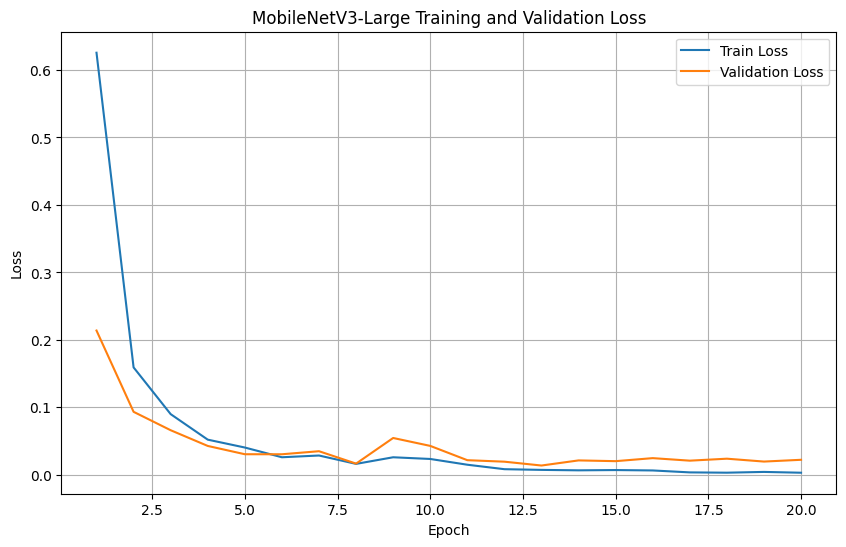

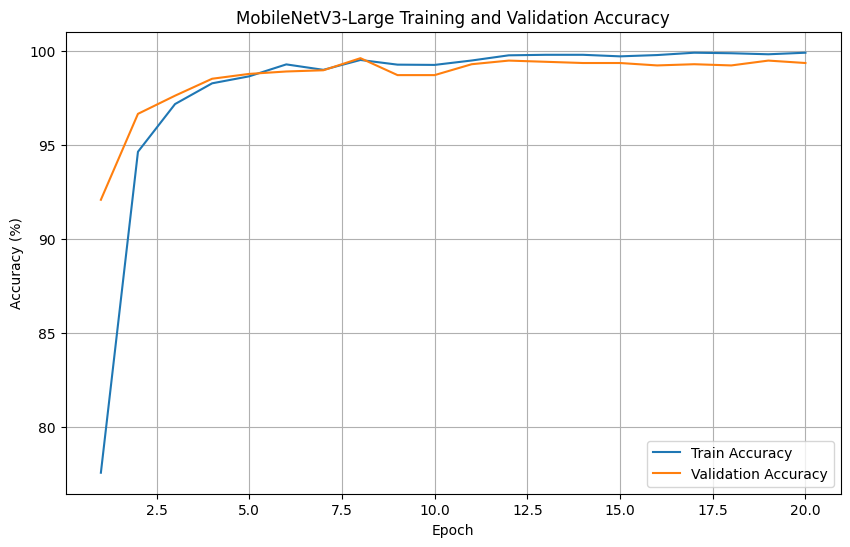

✓ Training curves saved


In [46]:
# ============================================================
# STEP 29 — TRAINING CURVES
# ============================================================

epochs_completed = range(
    1,
    len(
        history["train_loss"]
    ) + 1
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_completed,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_completed,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "MobileNetV3-Large Training and Validation Loss"
)

plt.legend()
plt.grid(True)

loss_plot = (
    VIS_DIR
    / "mobilenetv3_large_loss_curve.png"
)

plt.savefig(
    loss_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_completed,
    np.array(
        history["train_accuracy"]
    ) * 100,
    label="Train Accuracy"
)

plt.plot(
    epochs_completed,
    np.array(
        history["val_accuracy"]
    ) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "MobileNetV3-Large Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

accuracy_plot = (
    VIS_DIR
    / "mobilenetv3_large_accuracy_curve.png"
)

plt.savefig(
    accuracy_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Training curves saved"
)

# GENERIC EVALUATION FUNCTION

In [47]:
# ============================================================
# STEP 30 — EVALUATION FUNCTION
# ============================================================

@torch.no_grad()
def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    all_true = []
    all_pred = []
    all_probabilities = []
    all_confidences = []

    inference_start = time.time()

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidences, predictions = (
            probabilities.max(
                dim=1
            )
        )

        all_true.extend(
            labels.cpu().numpy()
        )

        all_pred.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

        all_confidences.extend(
            confidences.cpu().numpy()
        )

    inference_time = (
        time.time()
        - inference_start
    )

    return {
        "true_idx":
            np.array(all_true),

        "pred_idx":
            np.array(all_pred),

        "probabilities":
            np.array(
                all_probabilities
            ),

        "confidence":
            np.array(
                all_confidences
            ),

        "inference_time":
            inference_time
    }


print(
    "✓ Evaluation function ready"
)

✓ Evaluation function ready


# OVERALL TEST EVALUATION

In [48]:
# ============================================================
# STEP 31 — OVERALL TEST EVALUATION
# ============================================================

test_raw = evaluate_model(
    MODEL,
    test_loader,
    DEVICE
)

test_true = test_raw[
    "true_idx"
]

test_pred = test_raw[
    "pred_idx"
]

test_probabilities = test_raw[
    "probabilities"
]

test_confidence = test_raw[
    "confidence"
]

if len(test_true) != len(test_df):

    raise ValueError(
        "Test prediction count does not "
        "match test metadata."
    )

test_results = test_df.copy()

test_results[
    "true_idx"
] = test_true

test_results[
    "pred_idx"
] = test_pred

test_results[
    "true_class"
] = [
    IDX_TO_CLASS[idx]
    for idx in test_true
]

test_results[
    "pred_class"
] = [
    IDX_TO_CLASS[idx]
    for idx in test_pred
]

test_results[
    "confidence"
] = test_confidence

test_results[
    "correct"
] = (
    test_true
    == test_pred
)

print("=" * 80)
print("OVERALL TEST EVALUATION")
print("=" * 80)

print(
    "Test samples:",
    len(test_results)
)

print(
    "Correct:",
    int(
        test_results["correct"].sum()
    )
)

print(
    "Incorrect:",
    int(
        (~test_results["correct"]).sum()
    )
)

OVERALL TEST EVALUATION
Test samples: 1871
Correct: 1853
Incorrect: 18


# MAIN METRICS

In [49]:
# ============================================================
# STEP 32 — MAIN METRICS
# ============================================================

overall_accuracy = accuracy_score(
    test_true,
    test_pred
)

macro_precision = precision_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)

total_samples = len(
    test_true
)

total_errors = int(
    np.sum(
        test_true != test_pred
    )
)

error_rate = (
    total_errors
    / total_samples
)

print("=" * 80)
print("OVERALL TEST METRICS")
print("=" * 80)

print(
    f"Accuracy           : "
    f"{overall_accuracy*100:.4f}%"
)

print(
    f"Macro Precision    : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall       : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1           : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted Precision : "
    f"{weighted_precision:.4f}"
)

print(
    f"Weighted Recall    : "
    f"{weighted_recall:.4f}"
)

print(
    f"Weighted F1        : "
    f"{weighted_f1:.4f}"
)

print(
    f"Errors             : "
    f"{total_errors:,}"
)

print(
    f"Error Rate         : "
    f"{error_rate*100:.4f}%"
)

OVERALL TEST METRICS
Accuracy           : 99.0379%
Macro Precision    : 0.9901
Macro Recall       : 0.9906
Macro F1           : 0.9904
Weighted Precision : 0.9904
Weighted Recall    : 0.9904
Weighted F1        : 0.9904
Errors             : 18
Error Rate         : 0.9621%


# CLASSIFICATION REPORT

In [50]:
# ============================================================
# STEP 33 — CLASSIFICATION REPORT
# ============================================================

classification_report_dict = (
    classification_report(
        test_true,
        test_pred,
        labels=list(
            range(NUM_CLASSES)
        ),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

display(
    classification_report_df
)

classification_report_path = (
    REPORT_DIR
    / "mobilenetv3_large_classification_report.csv"
)

classification_report_df.to_csv(
    classification_report_path
)

print(
    "\nSaved:",
    classification_report_path
)

CLASSIFICATION REPORT


,precision,recall,f1-score,support
Cardboard,0.989051,0.996324,0.992674,272.000000
Glass,0.986737,1.000000,0.993324,372.000000
Metal,0.992000,0.978947,0.985430,380.000000
Paper,0.993789,0.991736,0.992761,484.000000
Plastic,0.988950,0.986226,0.987586,363.000000
accuracy,0.990379,0.990379,0.990379,0.990379
macro avg,0.990106,0.990646,0.990355,1871.000000
weighted avg,0.990396,0.990379,0.990368,1871.000000



Saved: /kaggle/working/mobilenetv3_large_experiment/reports/mobilenetv3_large_classification_report.csv


# CONFUSION MATRIX

CONFUSION MATRIX
[[271   0   0   1   0]
 [  0 372   0   0   0]
 [  0   2 372   2   4]
 [  3   1   0 480   0]
 [  0   2   3   0 358]]


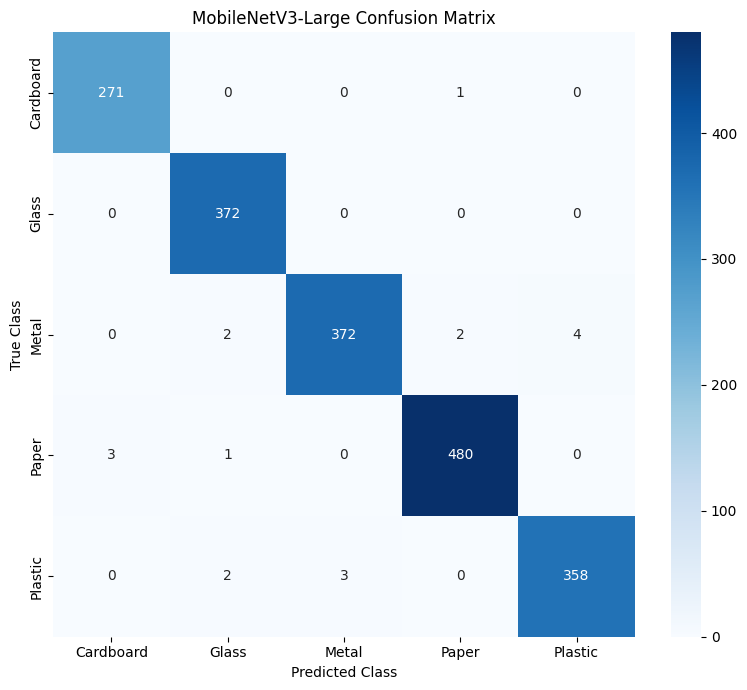


✓ Confusion matrix saved


In [51]:
# ============================================================
# STEP 34 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_true,
    test_pred,
    labels=list(
        range(NUM_CLASSES)
    )
)

print("=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)

print(cm)

plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "MobileNetV3-Large Confusion Matrix"
)

plt.tight_layout()

cm_path = (
    VIS_DIR
    / "mobilenetv3_large_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "\n✓ Confusion matrix saved"
)

# BANGLADESH TEST EVALUATION

In [52]:
# ============================================================
# STEP 35 — BANGLADESH TEST EVALUATION
# ============================================================

bd_raw = evaluate_model(
    MODEL,
    bd_test_loader,
    DEVICE
)

bd_true = bd_raw[
    "true_idx"
]

bd_pred = bd_raw[
    "pred_idx"
]

bd_probabilities = bd_raw[
    "probabilities"
]

bd_confidence = bd_raw[
    "confidence"
]

if len(bd_true) != len(
    bd_test_df
):

    raise ValueError(
        "Bangladesh prediction count "
        "does not match metadata."
    )

bd_accuracy = accuracy_score(
    bd_true,
    bd_pred
)

bd_macro_f1 = f1_score(
    bd_true,
    bd_pred,
    average="macro",
    zero_division=0
)

bd_results = bd_test_df.copy()

bd_results[
    "true_idx"
] = bd_true

bd_results[
    "pred_idx"
] = bd_pred

bd_results[
    "true_class"
] = [
    IDX_TO_CLASS[idx]
    for idx in bd_true
]

bd_results[
    "pred_class"
] = [
    IDX_TO_CLASS[idx]
    for idx in bd_pred
]

bd_results[
    "confidence"
] = bd_confidence

bd_results[
    "correct"
] = (
    bd_true
    == bd_pred
)

print("=" * 80)
print("BANGLADESH TEST RESULTS")
print("=" * 80)

print(
    f"Samples  : {len(bd_results):,}"
)

print(
    f"Accuracy : {bd_accuracy*100:.4f}%"
)

print(
    f"Macro F1 : {bd_macro_f1:.4f}"
)

print(
    f"Errors   : "
    f"{(~bd_results['correct']).sum():,}"
)

BANGLADESH TEST RESULTS
Samples  : 582
Accuracy : 97.4227%
Macro F1 : 0.9663
Errors   : 15


# INTERNATIONAL TEST EVALUATION

In [53]:
# ============================================================
# STEP 36 — INTERNATIONAL TEST EVALUATION
# ============================================================

intl_raw = evaluate_model(
    MODEL,
    intl_test_loader,
    DEVICE
)

intl_true = intl_raw[
    "true_idx"
]

intl_pred = intl_raw[
    "pred_idx"
]

intl_probabilities = intl_raw[
    "probabilities"
]

intl_confidence = intl_raw[
    "confidence"
]

if len(intl_true) != len(
    international_test_df
):

    raise ValueError(
        "International prediction count "
        "does not match metadata."
    )

intl_accuracy = accuracy_score(
    intl_true,
    intl_pred
)

intl_macro_f1 = f1_score(
    intl_true,
    intl_pred,
    average="macro",
    zero_division=0
)

intl_results = (
    international_test_df
    .copy()
)

intl_results[
    "true_idx"
] = intl_true

intl_results[
    "pred_idx"
] = intl_pred

intl_results[
    "true_class"
] = [
    IDX_TO_CLASS[idx]
    for idx in intl_true
]

intl_results[
    "pred_class"
] = [
    IDX_TO_CLASS[idx]
    for idx in intl_pred
]

intl_results[
    "confidence"
] = intl_confidence

intl_results[
    "correct"
] = (
    intl_true
    == intl_pred
)

print("=" * 80)
print("INTERNATIONAL TEST RESULTS")
print("=" * 80)

print(
    f"Samples  : "
    f"{len(intl_results):,}"
)

print(
    f"Accuracy : "
    f"{intl_accuracy*100:.4f}%"
)

print(
    f"Macro F1 : "
    f"{intl_macro_f1:.4f}"
)

print(
    f"Errors   : "
    f"{(~intl_results['correct']).sum():,}"
)

INTERNATIONAL TEST RESULTS
Samples  : 1,289
Accuracy : 99.7673%
Macro F1 : 0.9977
Errors   : 3


# EXPECTED CALIBRATION ERROR

In [54]:
# ============================================================
# STEP 37 — EXPECTED CALIBRATION ERROR
# ============================================================

def calculate_ece(
    y_true,
    probabilities,
    n_bins=10
):

    confidences = (
        np.max(
            probabilities,
            axis=1
        )
    )

    predictions = (
        np.argmax(
            probabilities,
            axis=1
        )
    )

    correctness = (
        predictions == y_true
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        lower = bin_edges[i]

        upper = bin_edges[i + 1]

        if i == n_bins - 1:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences >= lower)
                &
                (confidences < upper)
            )

        if not np.any(mask):

            continue

        bin_accuracy = (
            correctness[mask].mean()
        )

        bin_confidence = (
            confidences[mask].mean()
        )

        bin_fraction = (
            mask.mean()
        )

        ece += (
            bin_fraction
            *
            abs(
                bin_accuracy
                - bin_confidence
            )
        )

    return ece


ece = calculate_ece(
    test_true,
    test_probabilities,
    n_bins=10
)

print("=" * 80)
print("CALIBRATION")
print("=" * 80)

print(
    f"ECE: {ece:.6f}"
)

CALIBRATION
ECE: 0.004608


# RELIABILITY DIAGRAM

In [55]:
# ============================================================
# STEP 38A — CALIBRATION IMPORT FIX
# ============================================================

from sklearn.calibration import calibration_curve

print("=" * 80)
print("CALIBRATION DEPENDENCY CHECK")
print("=" * 80)

print("✓ calibration_curve imported successfully")

CALIBRATION DEPENDENCY CHECK
✓ calibration_curve imported successfully


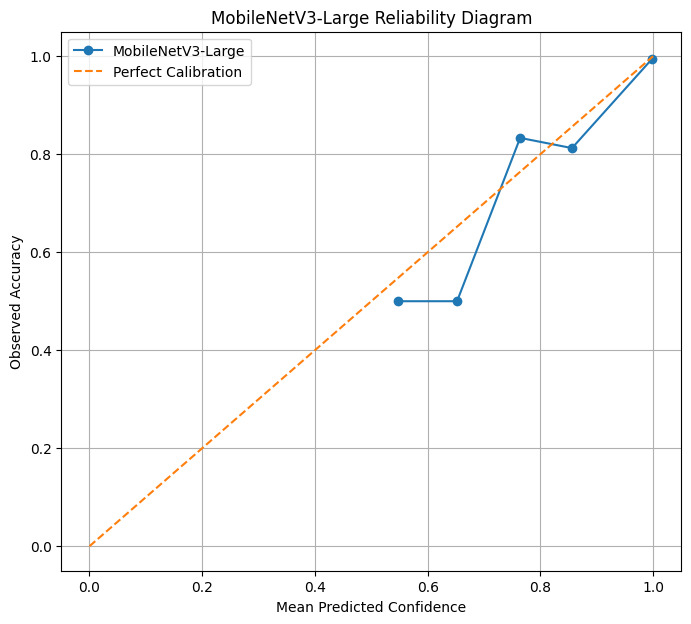

✓ Reliability diagram saved


In [56]:
# ============================================================
# STEP 38 — RELIABILITY DIAGRAM
# ============================================================

confidence_values = np.max(
    test_probabilities,
    axis=1
)

correctness_values = (
    test_pred == test_true
).astype(int)

prob_true, prob_pred = calibration_curve(
    correctness_values,
    confidence_values,
    n_bins=10,
    strategy="uniform"
)

plt.figure(
    figsize=(8, 7)
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="MobileNetV3-Large"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "MobileNetV3-Large Reliability Diagram"
)

plt.legend()
plt.grid(True)

reliability_path = (
    VIS_DIR
    / "mobilenetv3_large_reliability_diagram.png"
)

plt.savefig(
    reliability_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Reliability diagram saved"
)

# HIGH-CONFIDENCE ERROR ANALYSIS

In [57]:
# ============================================================
# STEP 39 — HIGH-CONFIDENCE ERROR ANALYSIS
# ============================================================

HIGH_CONF_THRESHOLD = 0.90

test_results[
    "confidence"
] = pd.to_numeric(
    test_results[
        "confidence"
    ],
    errors="coerce"
)

high_conf_errors = (
    test_results[
        (~test_results["correct"])
        &
        (
            test_results[
                "confidence"
            ]
            >= HIGH_CONF_THRESHOLD
        )
    ]
    .copy()
    .sort_values(
        "confidence",
        ascending=False
    )
)

print("=" * 80)
print("HIGH-CONFIDENCE ERROR ANALYSIS")
print("=" * 80)

print(
    f"Threshold             : "
    f"{HIGH_CONF_THRESHOLD:.0%}"
)

print(
    f"Total test samples    : "
    f"{len(test_results):,}"
)

print(
    f"Total errors          : "
    f"{(~test_results['correct']).sum():,}"
)

print(
    f"High-confidence errors: "
    f"{len(high_conf_errors):,}"
)

if len(high_conf_errors) > 0:

    display(
        high_conf_errors[
            [
                "filename",
                "true_class",
                "pred_class",
                "confidence"
            ]
        ]
    )

else:

    print(
        "\n✓ No high-confidence errors found."
    )

HIGH-CONFIDENCE ERROR ANALYSIS
Threshold             : 90%
Total test samples    : 1,871
Total errors          : 18
High-confidence errors: 9


,filename,true_class,pred_class,confidence
1393,INTL__Paper(413)_aug1.jpg,Paper,Cardboard,0.990029
879,INTL__Paper(413)_aug2.jpg,Paper,Cardboard,0.972561
722,BD__EWaste__train__IMG_20250805_204240_jpg.rf....,Metal,Plastic,0.960013
1179,BD__EWaste__train__IMG_20250822_141654_jpg.rf....,Metal,Glass,0.936931
1715,INTL__Plastic(241)_aug1.jpg,Plastic,Metal,0.929496
1676,BD__EWaste__train__IMG_20250822_141304_jpg.rf....,Metal,Paper,0.915594
1608,BD__AWaste__AWaste_Paper_20250419_235137.jpg,Paper,Glass,0.914625
864,BD__EWaste__valid__IMG_20250803_221347_jpg.rf....,Metal,Glass,0.907026
679,BD__BDWaste__Bangladesh_Cardboard__000009.jpg,Cardboard,Paper,0.905879


# ERROR ANALYSIS BY CLASS

In [58]:
# ============================================================
# STEP 40 — ERROR ANALYSIS BY CLASS
# ============================================================

error_by_class = (
    test_results
    .groupby("true_class")
    .agg(
        total=("true_class", "size"),
        errors=(
            "correct",
            lambda x: int(
                (~x).sum()
            )
        )
    )
)

error_by_class[
    "error_rate"
] = (
    error_by_class["errors"]
    /
    error_by_class["total"]
)

error_by_class[
    "accuracy"
] = (
    1
    -
    error_by_class["error_rate"]
)

error_by_class = (
    error_by_class
    .reindex(CLASS_NAMES)
)

print("=" * 80)
print("ERROR ANALYSIS BY TRUE CLASS")
print("=" * 80)

display(
    error_by_class
)

error_class_path = (
    REPORT_DIR
    / "mobilenetv3_large_error_by_class.csv"
)

error_by_class.to_csv(
    error_class_path
)

print(
    "\nSaved:",
    error_class_path
)

ERROR ANALYSIS BY TRUE CLASS


,total,errors,error_rate,accuracy
true_class,,,,
Cardboard,272,1,0.003676,0.996324
Glass,372,0,0.000000,1.000000
Metal,380,8,0.021053,0.978947
Paper,484,4,0.008264,0.991736
Plastic,363,5,0.013774,0.986226



Saved: /kaggle/working/mobilenetv3_large_experiment/reports/mobilenetv3_large_error_by_class.csv


#  SAVE TEST PREDICTIONS

In [59]:
# ============================================================
# STEP 41 — SAVE TEST PREDICTIONS
# ============================================================

test_results_path = (
    RESULT_DIR
    / "mobilenetv3_large_test_predictions.csv"
)

bd_results_path = (
    RESULT_DIR
    / "mobilenetv3_large_bangladesh_predictions.csv"
)

intl_results_path = (
    RESULT_DIR
    / "mobilenetv3_large_international_predictions.csv"
)

test_results.to_csv(
    test_results_path,
    index=False
)

bd_results.to_csv(
    bd_results_path,
    index=False
)

intl_results.to_csv(
    intl_results_path,
    index=False
)

print("=" * 80)
print("PREDICTION RESULTS SAVED")
print("=" * 80)

print(
    "Overall:",
    test_results_path
)

print(
    "Bangladesh:",
    bd_results_path
)

print(
    "International:",
    intl_results_path
)

PREDICTION RESULTS SAVED
Overall: /kaggle/working/mobilenetv3_large_experiment/results/mobilenetv3_large_test_predictions.csv
Bangladesh: /kaggle/working/mobilenetv3_large_experiment/results/mobilenetv3_large_bangladesh_predictions.csv
International: /kaggle/working/mobilenetv3_large_experiment/results/mobilenetv3_large_international_predictions.csv


# MODEL PERFORMANCE SUMMARY TABLE

In [60]:
# ============================================================
# STEP 42 — MODEL PERFORMANCE SUMMARY TABLE
# ============================================================

performance_summary = pd.DataFrame([
    {
        "Model":
            "MobileNetV3-Large",

        "Test Samples":
            len(test_results),

        "Accuracy":
            overall_accuracy,

        "Macro Precision":
            macro_precision,

        "Macro Recall":
            macro_recall,

        "Macro F1":
            macro_f1,

        "Weighted F1":
            weighted_f1,

        "Bangladesh Accuracy":
            bd_accuracy,

        "International Accuracy":
            intl_accuracy,

        "ECE":
            ece,

        "Errors":
            total_errors,

        "High Confidence Errors":
            len(high_conf_errors)
    }
])

print("=" * 80)
print("MOBILENETV3-LARGE PERFORMANCE SUMMARY")
print("=" * 80)

display(
    performance_summary
)

performance_path = (
    REPORT_DIR
    / "mobilenetv3_large_performance_summary.csv"
)

performance_summary.to_csv(
    performance_path,
    index=False
)

print(
    "\nSaved:",
    performance_path
)

MOBILENETV3-LARGE PERFORMANCE SUMMARY


,Model,Test Samples,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Bangladesh Accuracy,International Accuracy,ECE,Errors,High Confidence Errors
0,MobileNetV3-Large,1871,0.990379,0.990106,0.990646,0.990355,0.990368,0.974227,0.997673,0.004608,18,9



Saved: /kaggle/working/mobilenetv3_large_experiment/reports/mobilenetv3_large_performance_summary.csv


#  SAVE TRAINING HISTORY

In [61]:
# ============================================================
# STEP 43 — SAVE TRAINING HISTORY
# ============================================================

history_path = (
    REPORT_DIR
    / "mobilenetv3_large_training_history.json"
)

history_serializable = {
    key: [
        float(value)
        for value in values
    ]
    for key, values in history.items()
}

with open(
    history_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        history_serializable,
        file,
        indent=4
    )

print("=" * 80)
print("TRAINING HISTORY SAVED")
print("=" * 80)

print(
    history_path
)

TRAINING HISTORY SAVED
/kaggle/working/mobilenetv3_large_experiment/reports/mobilenetv3_large_training_history.json


#  FINAL RESEARCH SUMMARY

In [62]:
# ============================================================
# STEP 44 — FINAL RESEARCH SUMMARY
# ============================================================

summary = {

    "experiment": {
        "model":
            "MobileNetV3-Large",

        "architecture":
            "MobileNetV3-Large",

        "framework":
            "PyTorch",

        "device":
            str(DEVICE),

        "gpu":
            (
                torch.cuda.get_device_name(0)
                if torch.cuda.is_available()
                else "CPU"
            ),

        "seed":
            SEED,

        "image_size":
            IMG_SIZE,

        "batch_size":
            BATCH_SIZE,

        "epochs_configured":
            EPOCHS,

        "epochs_completed":
            len(
                history[
                    "train_loss"
                ]
            ),

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "best_epoch":
            int(best_epoch),

        "training_time_minutes":
            float(
                training_time / 60
            )
    },

    "dataset": {

        "total_images":
            int(len(final_df)),

        "train":
            int(len(train_df)),

        "validation":
            int(len(val_df)),

        "test":
            int(len(test_df)),

        "bangladesh_test":
            int(len(bd_test_df)),

        "international_test":
            int(
                len(
                    international_test_df
                )
            ),

        "classes":
            CLASS_NAMES,

        "num_classes":
            NUM_CLASSES,

        "class_imbalance_ratio":
            float(imbalance_ratio)
    },

    "overall_test": {

        "accuracy":
            float(
                overall_accuracy
            ),

        "precision_macro":
            float(
                macro_precision
            ),

        "recall_macro":
            float(
                macro_recall
            ),

        "f1_macro":
            float(
                macro_f1
            ),

        "precision_weighted":
            float(
                weighted_precision
            ),

        "recall_weighted":
            float(
                weighted_recall
            ),

        "f1_weighted":
            float(
                weighted_f1
            ),

        "error_rate":
            float(
                error_rate
            ),

        "total_errors":
            int(
                total_errors
            ),

        "ece":
            float(ece)
    },

    "country_analysis": {

        "bangladesh": {

            "samples":
                int(
                    len(bd_results)
                ),

            "accuracy":
                float(
                    bd_accuracy
                ),

            "macro_f1":
                float(
                    bd_macro_f1
                ),

            "errors":
                int(
                    (
                        ~bd_results[
                            "correct"
                        ]
                    ).sum()
                )
        },

        "international": {

            "samples":
                int(
                    len(intl_results)
                ),

            "accuracy":
                float(
                    intl_accuracy
                ),

            "macro_f1":
                float(
                    intl_macro_f1
                ),

            "errors":
                int(
                    (
                        ~intl_results[
                            "correct"
                        ]
                    ).sum()
                )
        }
    },

    "error_analysis": {

        "high_confidence_threshold":
            HIGH_CONF_THRESHOLD,

        "high_confidence_errors":
            int(
                len(
                    high_conf_errors
                )
            )
    },

    "model_parameters": {

        "total":
            int(
                total_parameters
            ),

        "trainable":
            int(
                trainable_parameters
            )
    }
}

summary_path = (
    REPORT_DIR
    / "mobilenetv3_large_final_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=4,
        ensure_ascii=False
    )

print("=" * 80)
print("MOBILENETV3-LARGE FINAL RESEARCH SUMMARY")
print("=" * 80)

print(
    f"Overall Accuracy       : "
    f"{overall_accuracy*100:.4f}%"
)

print(
    f"Macro Precision        : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall           : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1               : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted F1            : "
    f"{weighted_f1:.4f}"
)

print(
    f"Bangladesh Accuracy    : "
    f"{bd_accuracy*100:.4f}%"
)

print(
    f"International Accuracy : "
    f"{intl_accuracy*100:.4f}%"
)

print(
    f"ECE                    : "
    f"{ece:.6f}"
)

print(
    f"Misclassified          : "
    f"{total_errors:,}"
)

print(
    f"High-conf errors       : "
    f"{len(high_conf_errors):,}"
)

print(
    "\nSummary saved:",
    summary_path
)

MOBILENETV3-LARGE FINAL RESEARCH SUMMARY
Overall Accuracy       : 99.0379%
Macro Precision        : 0.9901
Macro Recall           : 0.9906
Macro F1               : 0.9904
Weighted F1            : 0.9904
Bangladesh Accuracy    : 97.4227%
International Accuracy : 99.7673%
ECE                    : 0.004608
Misclassified          : 18
High-conf errors       : 9

Summary saved: /kaggle/working/mobilenetv3_large_experiment/reports/mobilenetv3_large_final_summary.json


# FINAL OUTPUT AUDIT

In [63]:
# ============================================================
# STEP 45 — FINAL OUTPUT AUDIT
# ============================================================

print("=" * 80)
print("FINAL OUTPUT AUDIT")
print("=" * 80)

expected_outputs = [

    CHECKPOINT_DIR
    / "mobilenetv3_large_best.pth",

    REPORT_DIR
    / "mobilenetv3_large_final_summary.json",

    REPORT_DIR
    / "mobilenetv3_large_classification_report.csv",

    REPORT_DIR
    / "mobilenetv3_large_error_by_class.csv",

    REPORT_DIR
    / "mobilenetv3_large_performance_summary.csv",

    REPORT_DIR
    / "mobilenetv3_large_training_history.json",

    RESULT_DIR
    / "mobilenetv3_large_test_predictions.csv",

    RESULT_DIR
    / "mobilenetv3_large_bangladesh_predictions.csv",

    RESULT_DIR
    / "mobilenetv3_large_international_predictions.csv",

    VIS_DIR
    / "mobilenetv3_large_loss_curve.png",

    VIS_DIR
    / "mobilenetv3_large_accuracy_curve.png",

    VIS_DIR
    / "mobilenetv3_large_confusion_matrix.png",

    VIS_DIR
    / "mobilenetv3_large_reliability_diagram.png"
]

missing_outputs = []

for path in expected_outputs:

    if path.exists():

        size_mb = (
            path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"✓ {path.name:<55} "
            f"{size_mb:.2f} MB"
        )

    else:

        print(
            f"✗ MISSING: {path}"
        )

        missing_outputs.append(
            path
        )

print(
    "\nExpected outputs:",
    len(expected_outputs)
)

print(
    "Missing outputs:",
    len(missing_outputs)
)

if missing_outputs:

    raise FileNotFoundError(
        "Some expected research outputs "
        "were not generated."
    )

print(
    "\n✓ ALL MOBILE NET V3 LARGE "
    "RESEARCH OUTPUTS VERIFIED"
)

FINAL OUTPUT AUDIT
✓ mobilenetv3_large_best.pth                              48.51 MB
✓ mobilenetv3_large_final_summary.json                    0.00 MB
✓ mobilenetv3_large_classification_report.csv             0.00 MB
✓ mobilenetv3_large_error_by_class.csv                    0.00 MB
✓ mobilenetv3_large_performance_summary.csv               0.00 MB
✓ mobilenetv3_large_training_history.json                 0.00 MB
✓ mobilenetv3_large_test_predictions.csv                  0.41 MB
✓ mobilenetv3_large_bangladesh_predictions.csv            0.17 MB
✓ mobilenetv3_large_international_predictions.csv         0.31 MB
✓ mobilenetv3_large_loss_curve.png                        0.13 MB
✓ mobilenetv3_large_accuracy_curve.png                    0.13 MB
✓ mobilenetv3_large_confusion_matrix.png                  0.13 MB
✓ mobilenetv3_large_reliability_diagram.png               0.15 MB

Expected outputs: 13
Missing outputs: 0

✓ ALL MOBILE NET V3 LARGE RESEARCH OUTPUTS VERIFIED


# FINAL RESEARCH DISPLAY

In [64]:
# ============================================================
# STEP 46 — FINAL RESEARCH DISPLAY
# ============================================================

print("\n")
print("=" * 80)
print("MOBILENETV3-LARGE FINAL RESEARCH RESULT")
print("=" * 80)

print(
    f"""
Model                   : MobileNetV3-Large

Dataset                 : Final Waste Dataset

Classes                 : 5
Total Images            : {len(final_df):,}

Train                   : {len(train_df):,}
Validation              : {len(val_df):,}
Test                    : {len(test_df):,}

Bangladesh Test         : {len(bd_test_df):,}
International Test      : {len(international_test_df):,}

------------------------------------------------------------

Overall Accuracy       : {overall_accuracy*100:.4f}%

Macro Precision        : {macro_precision:.4f}
Macro Recall           : {macro_recall:.4f}
Macro F1               : {macro_f1:.4f}

Weighted Precision     : {weighted_precision:.4f}
Weighted Recall        : {weighted_recall:.4f}
Weighted F1            : {weighted_f1:.4f}

------------------------------------------------------------

Bangladesh Accuracy    : {bd_accuracy*100:.4f}%
International Accuracy : {intl_accuracy*100:.4f}%

ECE                    : {ece:.6f}

Misclassified          : {total_errors:,}
High-conf errors       : {len(high_conf_errors):,}

------------------------------------------------------------

Best Epoch             : {best_epoch}
Training Time          : {training_time/60:.2f} minutes

------------------------------------------------------------

Final Summary:

{summary_path}
"""
)

print("=" * 80)
print("✓ MOBILENETV3-LARGE EXPERIMENT COMPLETE")
print("=" * 80)



MOBILENETV3-LARGE FINAL RESEARCH RESULT

Model                   : MobileNetV3-Large

Dataset                 : Final Waste Dataset

Classes                 : 5
Total Images            : 10,668

Train                   : 7,245
Validation              : 1,552
Test                    : 1,871

Bangladesh Test         : 582
International Test      : 1,289

------------------------------------------------------------

Overall Accuracy       : 99.0379%

Macro Precision        : 0.9901
Macro Recall           : 0.9906
Macro F1               : 0.9904

Weighted Precision     : 0.9904
Weighted Recall        : 0.9904
Weighted F1            : 0.9904

------------------------------------------------------------

Bangladesh Accuracy    : 97.4227%
International Accuracy : 99.7673%

ECE                    : 0.004608

Misclassified          : 18
High-conf errors       : 9

------------------------------------------------------------

Best Epoch             : 13
Training Time          : 42.48 minutes



In [65]:
# ============================================================
# STEP 60 — CREATE COMPLETE EFFICIENTNET-B0 ZIP
# ============================================================

import shutil

ZIP_BASE = Path(
    "/kaggle/working/MOBILENETV3-LARGE_complete_backup"
)

# Remove old ZIP if it exists
old_zip = Path(
    str(ZIP_BASE) + ".zip"
)

if old_zip.exists():

    old_zip.unlink()

print("=" * 80)
print("CREATING EFFICIENTNET-B0 BACKUP ZIP")
print("=" * 80)

zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=OUTPUT_ROOT.parent,
    base_dir=OUTPUT_ROOT.name
)

print("\n✓ ZIP CREATED")
print(zip_path)

zip_size_mb = (
    Path(zip_path).stat().st_size
    / (1024 * 1024)
)

print(
    f"ZIP size: {zip_size_mb:.2f} MB"
)

CREATING EFFICIENTNET-B0 BACKUP ZIP

✓ ZIP CREATED
/kaggle/working/MOBILENETV3-LARGE_complete_backup.zip
ZIP size: 45.20 MB


In [66]:
# ============================================================
# STEP 61 — VERIFY ZIP
# ============================================================

import zipfile

ZIP_PATH = Path(zip_path)

print("=" * 80)
print("VERIFYING EFFICIENTNET-B0 ZIP")
print("=" * 80)

if not ZIP_PATH.exists():

    raise FileNotFoundError(
        "ZIP file was not created."
    )

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as z:

    bad_file = z.testzip()

    if bad_file is not None:

        raise RuntimeError(
            f"Corrupted file inside ZIP: {bad_file}"
        )

    zip_members = z.namelist()

print("✓ ZIP integrity check passed")

print(
    f"Files inside ZIP: {len(zip_members):,}"
)

print("\nCheckpoint files inside ZIP:")

for member in zip_members:

    if member.lower().endswith(
        (".pth", ".pt", ".ckpt")
    ):

        print("→", member)

print("\n✓ mobilenetv3_large backup is ready")

VERIFYING EFFICIENTNET-B0 ZIP
✓ ZIP integrity check passed
Files inside ZIP: 18

Checkpoint files inside ZIP:
→ mobilenetv3_large_experiment/checkpoints/mobilenetv3_large_best.pth

✓ mobilenetv3_large backup is ready
